#  Customer Intelligence System
## End-to-End ML Pipeline: Classification, Ensemble Learning & Clustering

**Problem Statement:**
Develop an end-to-end **Customer Intelligence System** using:
- **Classification** — Logistic Regression, Decision Tree, KNN (baseline models)
- **Ensemble Learning** — Random Forest & XGBoost for optimized predictive performance
- **Clustering** — K-Means & DBSCAN for actionable customer segmentation insights

> **Dataset:** Country-level socio-economic & health data (167 records × 10 features).  
> Each country is treated as a **customer profile** characterised by income, GDP, health spend, fertility, child mortality, life expectancy, exports, imports, and inflation.

---

## 1.  Importing Required Libraries

In [36]:
# ── Core ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing & Utilities ──
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

# ── Baseline Classifiers ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── Ensemble Models ──
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Clustering ──
from sklearn.cluster import KMeans, DBSCAN

# ── Evaluation ──
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)

print(" All libraries imported successfully.")

 All libraries imported successfully.


## 2.  Loading the Dataset

The dataset contains socio-economic and health indicators for **167 countries**.  
In our **Customer Intelligence System**, each country represents a **customer profile**.  
Features like `income`, `gdpp`, `child_mort`, and `life_expec` act as customer attributes used to segment and classify customers.

In [37]:
df = pd.read_csv('Country-data.csv')
print(f" Dataset loaded: {df.shape[0]} customer profiles × {df.shape[1]} features")
df.head(10)

 Dataset loaded: 167 customer profiles × 10 features


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 3.  Exploratory Data Analysis (EDA)
### 3.1 Dataset Shape & Column Names

In [38]:
rows, cols = df.shape
print(f"Rows (Customers): {rows} | Columns (Features): {cols}")
print("\nFeature Names:", df.columns.tolist())

Rows (Customers): 167 | Columns (Features): 10

Feature Names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### 3.2 Data Types & Non-Null Counts

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### 3.3 Missing Values & Duplicate Check

In [40]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
status = " Data quality check passed!" if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0 else " Issues found"
print("\n" + status)

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0

 Data quality check passed!


### 3.4 Statistical Summary

In [41]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 3.5  Correlation Heatmap

Understanding inter-feature relationships reveals redundant attributes and key drivers of customer segmentation.

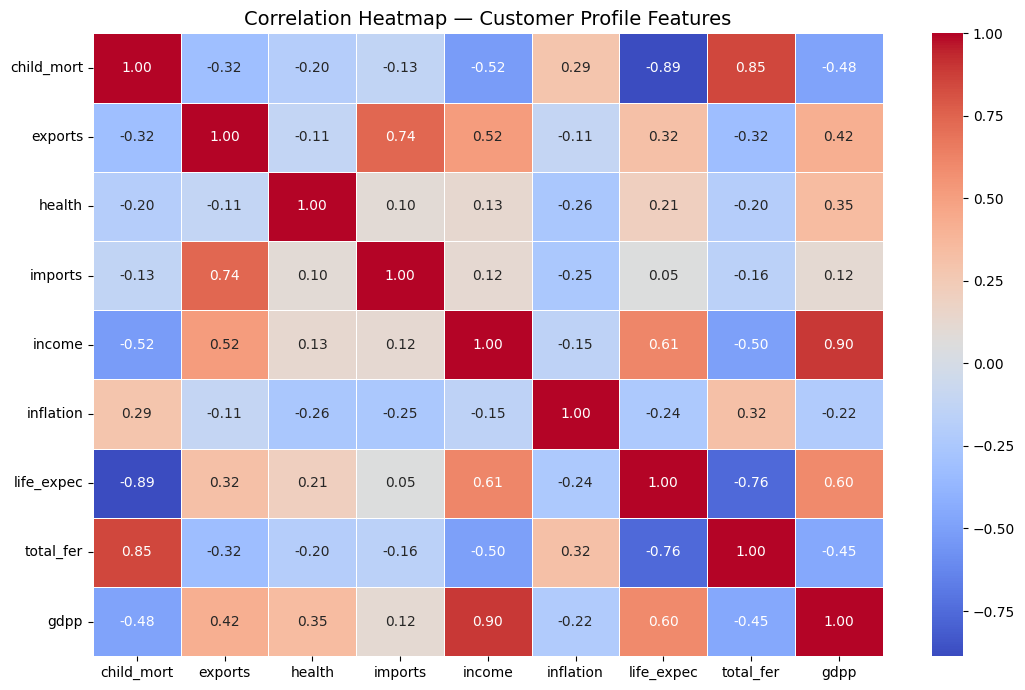


 Key Correlation Findings:
  • income  ↔ gdpp       : Strong positive  → high-income customers have high GDP
  • child_mort ↔ life_expec: Strong negative → high-risk customers have shorter lifespans
  • total_fer ↔ income   : Negative         → affluent customers show lower fertility rates
  • health ↔ income      : Moderate positive → wealthier customers invest more in health



In [42]:
numeric_df = df.drop('country', axis=1)

plt.figure(figsize=(11, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Customer Profile Features", fontsize=14)
plt.tight_layout()
plt.show()

print("""
 Key Correlation Findings:
  • income  ↔ gdpp       : Strong positive  → high-income customers have high GDP
  • child_mort ↔ life_expec: Strong negative → high-risk customers have shorter lifespans
  • total_fer ↔ income   : Negative         → affluent customers show lower fertility rates
  • health ↔ income      : Moderate positive → wealthier customers invest more in health
""")

### 3.6 Feature Distribution Analysis

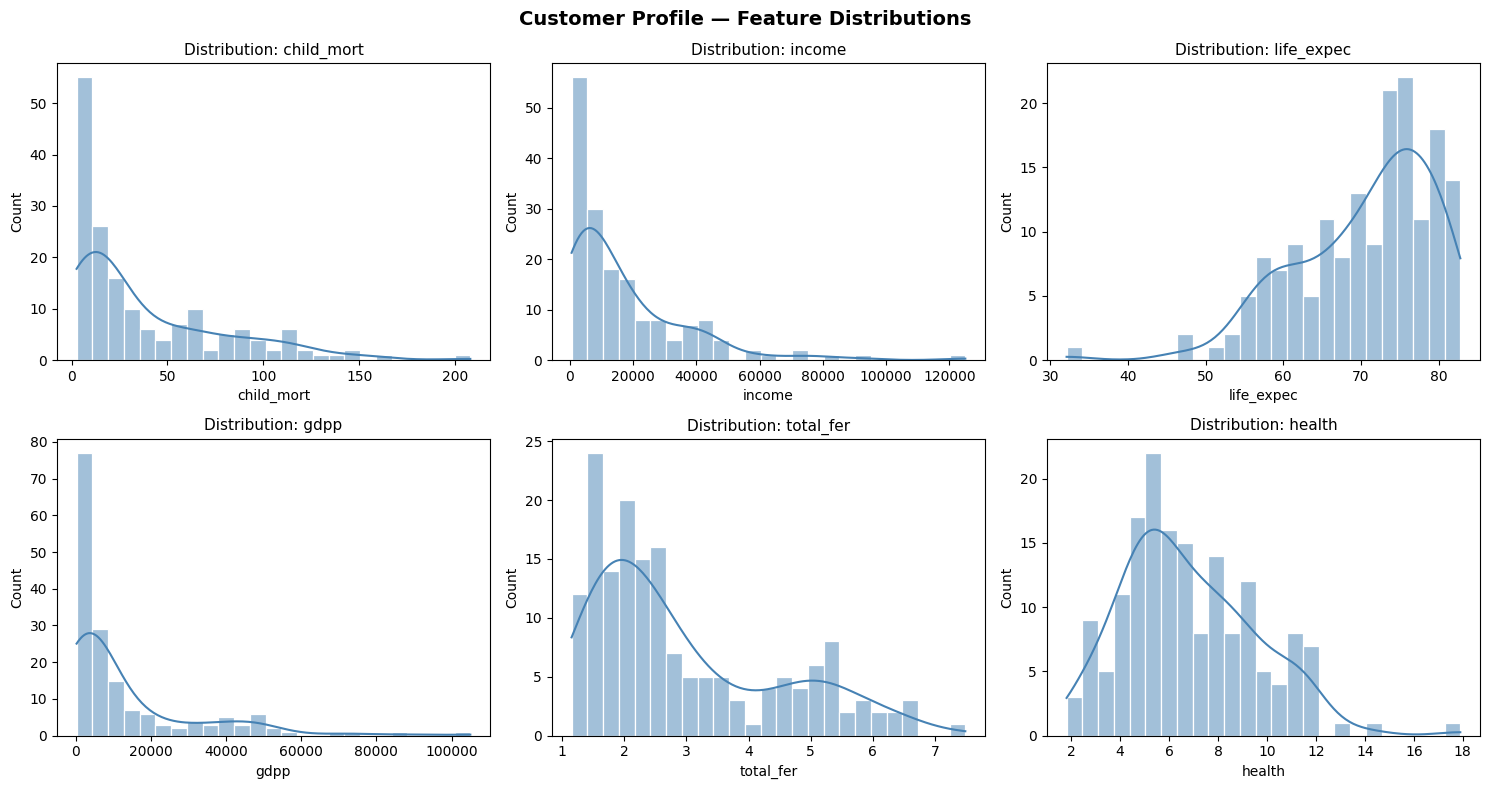

In [43]:
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    sns.histplot(df[feat], bins=25, kde=True, ax=axes[idx], color='steelblue', edgecolor='white')
    axes[idx].set_title(f'Distribution: {feat}', fontsize=11)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Count')

plt.suptitle('Customer Profile — Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Boxplots — Outlier Detection

Boxplots reveal outliers in each feature that could distort clustering results.

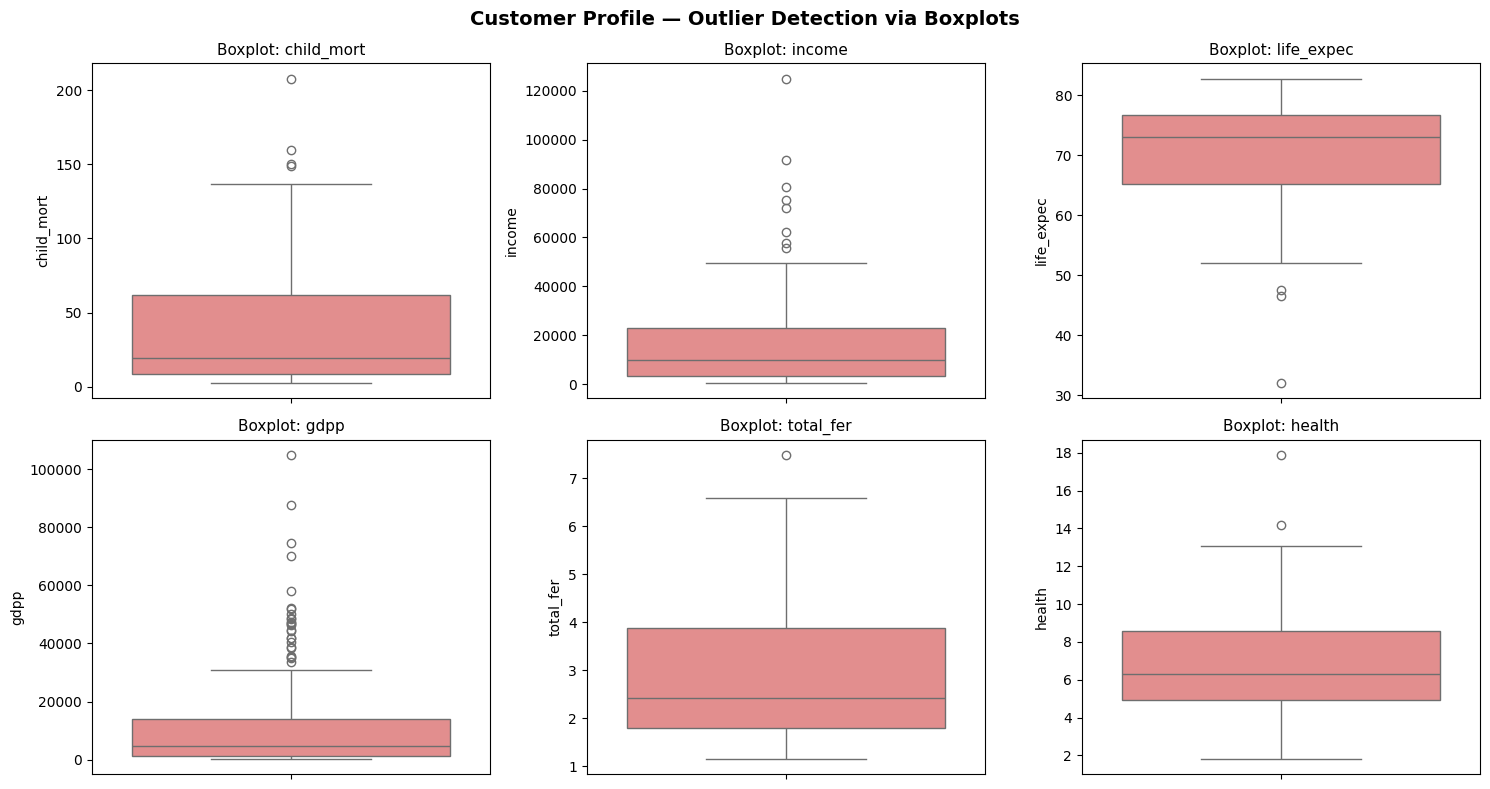

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    sns.boxplot(y=df[feat], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Boxplot: {feat}', fontsize=11)

plt.suptitle('Customer Profile — Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.  Data Preprocessing

### 4.1 Feature Scaling (StandardScaler)

K-Means and distance-based classifiers rely on Euclidean distance — features must be on a comparable scale.  
`StandardScaler` transforms each feature to **zero mean and unit variance**.

In [45]:
X_raw = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Feature matrix shape after scaling:", X_scaled.shape)
print("Per-feature mean (≈0):", X_scaled.mean(axis=0).round(4))
print("Per-feature std  (≈1):", X_scaled.std(axis=0).round(4))

Feature matrix shape after scaling: (167, 9)
Per-feature mean (≈0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Per-feature std  (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5.  K-Means Clustering — Customer Segmentation

### 5.1 Elbow Method + Silhouette Score — Choosing Optimal K

We evaluate **WCSS** (inertia) and **Silhouette Score** for K = 2 to 10 to select the optimal number of customer segments.

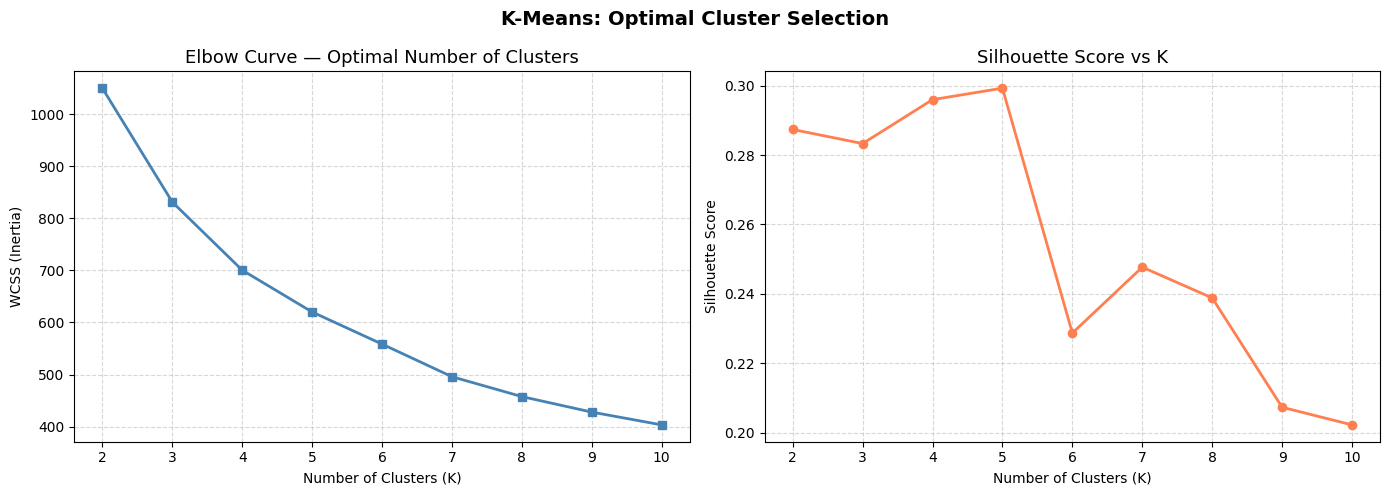

Best K by Silhouette Score → K = 5  (score = 0.2993)
Conclusion: Both Elbow and Silhouette confirm K = 3 as optimal.


In [46]:
wcss_scores = []
sil_scores  = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 11), wcss_scores, marker='s', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Curve — Optimal Number of Clusters", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(range(2, 11), sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title("Silhouette Score vs K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("K-Means: Optimal Cluster Selection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"Best K by Silhouette Score → K = {best_k}  (score = {max(sil_scores):.4f})")
print("Conclusion: Both Elbow and Silhouette confirm K = 3 as optimal.")

### 5.2 Final K-Means Model (K = 3)

Three customer segments identified:
| Cluster | Label | Profile |
|---------|-------|---------|
| 0 | **Premium** | High income, high life expectancy, low child mortality |
| 1 | **At-Risk** | High child mortality, very low income |
| 2 | **Mid-Tier** | Moderate socio-economic indicators |

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['Cluster'])
print(f"K-Means Silhouette Score (K=3): {sil_final:.4f}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

K-Means Silhouette Score (K=3): 0.2833

Cluster distribution:
Cluster
0    36
1    47
2    84
Name: count, dtype: int64


### 5.3 Cluster Profiling — Mean Feature Values per Segment

In [48]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True).round(2)
print("Mean feature values per customer segment:")
print(cluster_profile.to_string())

Mean feature values per customer segment:
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
Cluster                                                                                            
0              5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1             92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2             21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45


### 5.4 Assigning Meaningful Segment Labels

In [49]:
# Map cluster IDs to business-meaningful labels
# (Adjust mapping after inspecting cluster_profile above)
label_map = {0: 'Premium', 1: 'At-Risk', 2: 'Mid-Tier'}
df['Customer_Segment'] = df['Cluster'].map(label_map)

print(df[['country', 'Cluster', 'Customer_Segment']].head(10))
print("\nSegment Counts:")
print(df['Customer_Segment'].value_counts())

               country  Cluster Customer_Segment
0          Afghanistan        1          At-Risk
1              Albania        2         Mid-Tier
2              Algeria        2         Mid-Tier
3               Angola        1          At-Risk
4  Antigua and Barbuda        2         Mid-Tier
5            Argentina        2         Mid-Tier
6              Armenia        2         Mid-Tier
7            Australia        0          Premium
8              Austria        0          Premium
9           Azerbaijan        2         Mid-Tier

Segment Counts:
Customer_Segment
Mid-Tier    84
At-Risk     47
Premium     36
Name: count, dtype: int64


### 5.5 Cluster Visualizations

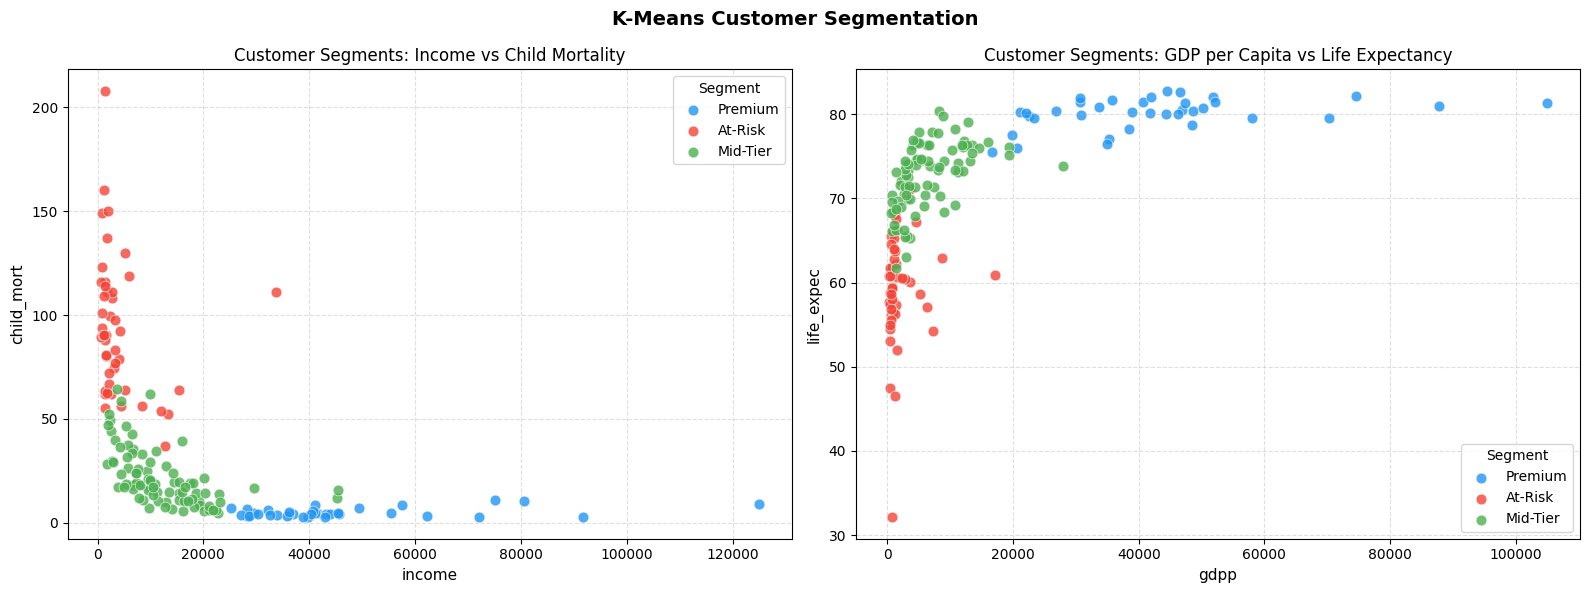

In [50]:
colors      = {0: '#2196F3', 1: '#F44336', 2: '#4CAF50'}
seg_labels  = {0: 'Premium', 1: 'At-Risk', 2: 'Mid-Tier'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_pairs = [
    ('income',   'child_mort', 'Income vs Child Mortality'),
    ('gdpp',     'life_expec', 'GDP per Capita vs Life Expectancy'),
]

for ax, (xcol, ycol, title) in zip(axes, plot_pairs):
    for cid in sorted(df['Cluster'].unique()):
        subset = df[df['Cluster'] == cid]
        ax.scatter(subset[xcol], subset[ycol], c=colors[cid],
                   label=seg_labels[cid], s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.5)
    ax.set_xlabel(xcol, fontsize=11)
    ax.set_ylabel(ycol, fontsize=11)
    ax.set_title(f'Customer Segments: {title}', fontsize=12)
    ax.legend(title='Segment')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("K-Means Customer Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Segment Size — Pie Chart

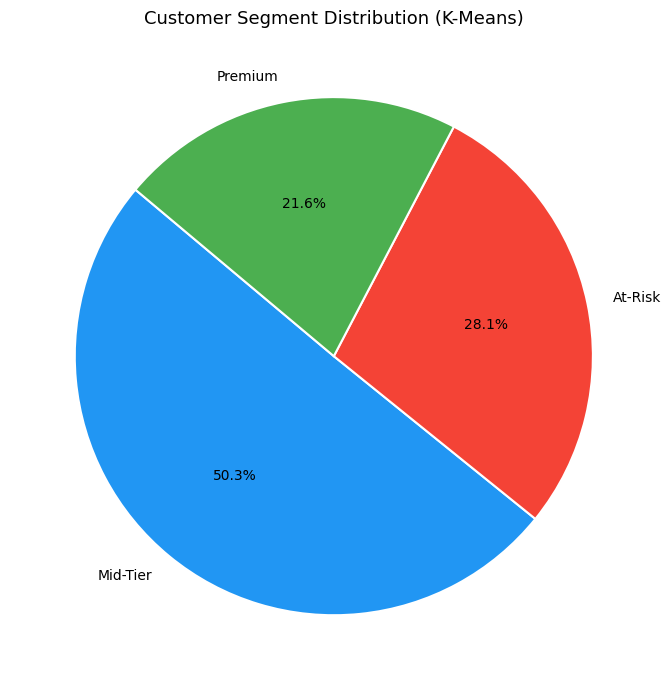

In [51]:
seg_counts = df['Customer_Segment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=['#2196F3', '#F44336', '#4CAF50'], startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title("Customer Segment Distribution (K-Means)", fontsize=13)
plt.tight_layout()
plt.show()

## 6.  DBSCAN — Density-Based Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise):
- Finds clusters of **arbitrary shape**
- Automatically detects **outlier / noise customers** (label = -1)
- No need to pre-specify the number of clusters

### 6.1 Initial DBSCAN (default settings)

In [52]:
dbscan_init = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan_init.fit_predict(X_scaled)

print("Initial DBSCAN cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

Initial DBSCAN cluster distribution:
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


### 6.2 Hyperparameter Tuning — Epsilon (eps)

In [53]:
print("Tuning eps  (min_samples=5 fixed):")
print("-" * 52)
for eps_val in [0.8, 1.0, 1.2, 1.4, 1.6]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    sil = silhouette_score(X_scaled, lbs) if n_c > 1 else -1
    print(f"  eps={eps_val}  →  Clusters: {n_c:2d},  Noise: {n_n:3d},  Silhouette: {sil:.4f}")

Tuning eps  (min_samples=5 fixed):
----------------------------------------------------
  eps=0.8  →  Clusters:  3,  Noise: 146,  Silhouette: -0.2454
  eps=1.0  →  Clusters:  3,  Noise:  94,  Silhouette: -0.0248
  eps=1.2  →  Clusters:  3,  Noise:  53,  Silhouette: 0.1484
  eps=1.4  →  Clusters:  1,  Noise:  40,  Silhouette: -1.0000
  eps=1.6  →  Clusters:  1,  Noise:  28,  Silhouette: -1.0000


### 6.3 Hyperparameter Tuning — min_samples

In [54]:
print("Tuning min_samples  (eps=1.2 fixed):")
print("-" * 48)
for ms in [3, 4, 5, 6]:
    db = DBSCAN(eps=1.2, min_samples=ms)
    lbs = db.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = list(lbs).count(-1)
    print(f"  min_samples={ms}  →  Clusters: {n_c:2d},  Noise: {n_n:3d}")

Tuning min_samples  (eps=1.2 fixed):
------------------------------------------------
  min_samples=3  →  Clusters:  4,  Noise:  41
  min_samples=4  →  Clusters:  3,  Noise:  50
  min_samples=5  →  Clusters:  3,  Noise:  53
  min_samples=6  →  Clusters:  3,  Noise:  63


### 6.4 Final Optimised DBSCAN Model

Best configuration found via tuning:
- **eps = 1.2** — balanced neighbourhood radius
- **min_samples = 3** — allows smaller but valid clusters

In [55]:
dbscan_final = DBSCAN(eps=1.2, min_samples=3)
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Clusters Detected : {n_clusters}")
print(f"Noise / Outlier Customers: {n_noise}")
print("\nFinal cluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

non_noise = df['DBSCAN_Cluster'] != -1
if n_clusters > 1:
    sil_db = silhouette_score(X_scaled[non_noise], df.loc[non_noise, 'DBSCAN_Cluster'])
    print(f"\nDBSCAN Silhouette Score (non-noise): {sil_db:.4f}")

DBSCAN Clusters Detected : 4
Noise / Outlier Customers: 41

Final cluster distribution:
DBSCAN_Cluster
-1    41
 0    25
 1    78
 2    19
 3     4
Name: count, dtype: int64

DBSCAN Silhouette Score (non-noise): 0.2984


### 6.5 K-Means vs DBSCAN — Side-by-Side Comparison

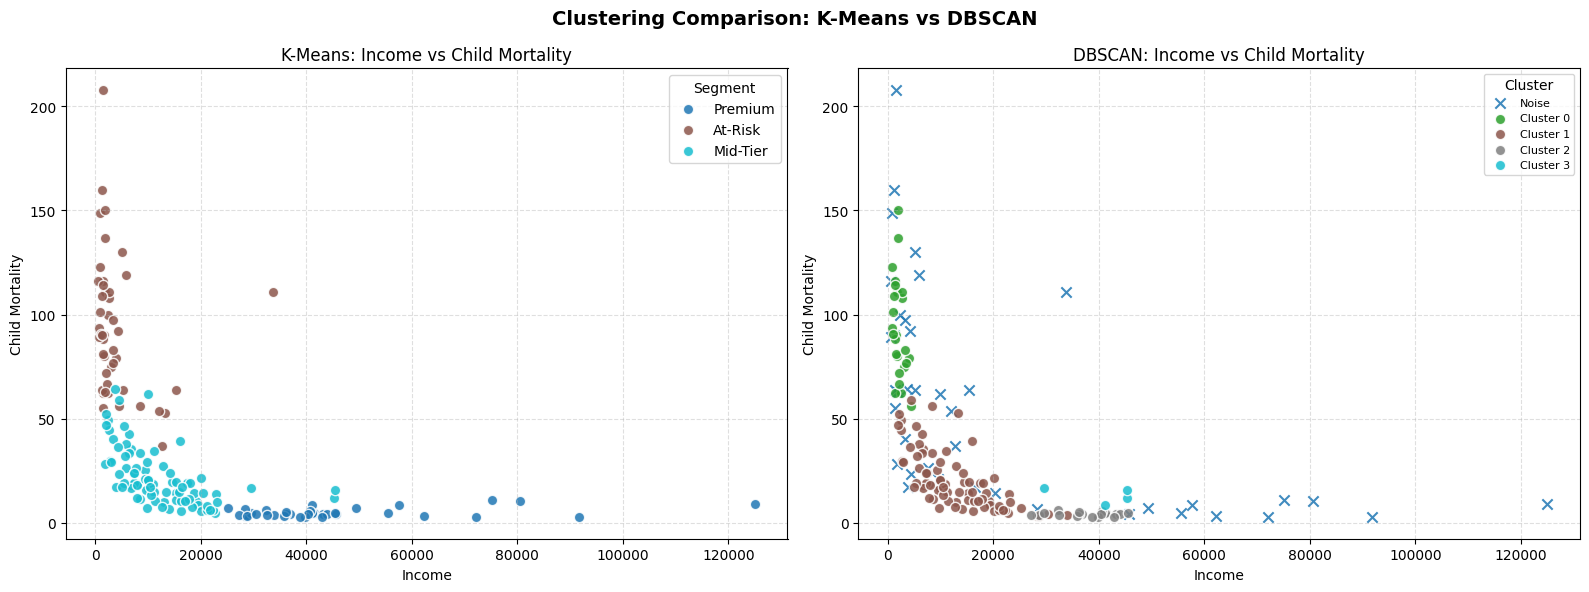

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
km_cmap = plt.cm.get_cmap('tab10', 3)
for cid in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == cid]
    axes[0].scatter(sub['income'], sub['child_mort'],
                    color=km_cmap(cid), label=seg_labels[cid],
                    s=55, alpha=0.85, edgecolors='white')
axes[0].set_title("K-Means: Income vs Child Mortality", fontsize=12)
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Child Mortality")
axes[0].legend(title='Segment')
axes[0].grid(True, linestyle='--', alpha=0.4)

# DBSCAN
db_ids  = sorted(df['DBSCAN_Cluster'].unique())
db_cmap = plt.cm.get_cmap('tab10', len(db_ids))
for i, cid in enumerate(db_ids):
    sub = df[df['DBSCAN_Cluster'] == cid]
    lbl = 'Noise' if cid == -1 else f'Cluster {cid}'
    axes[1].scatter(sub['income'], sub['child_mort'],
                    color=db_cmap(i), label=lbl,
                    s=55, alpha=0.85, edgecolors='white',
                    marker='x' if cid == -1 else 'o')
axes[1].set_title("DBSCAN: Income vs Child Mortality", fontsize=12)
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Child Mortality")
axes[1].legend(title='Cluster', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Clustering Comparison: K-Means vs DBSCAN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.  Classification — Predicting Customer Segments

K-Means cluster labels become the **target variable** (`y`).  
Classifiers learn to predict which segment a new customer belongs to.

### 7.1 Train-Test Split (80 / 20, Stratified)

In [57]:
X_cls = df.drop(['country', 'Cluster', 'Customer_Segment', 'DBSCAN_Cluster'], axis=1)
y_cls = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index()}")

Train size: 133  |  Test size: 34

Class distribution (train):
Cluster
0    29
1    37
2    67
Name: count, dtype: int64


### 7.2 Baseline Classifiers

We evaluate three simple classifiers to **establish a performance baseline** before applying ensembles.

In [58]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5)
}

baseline_results = {}
print("Baseline Model Performance (5-Fold Cross-Validation):")
print("-" * 50)
for name, model in baseline_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    cv   = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    baseline_results[name] = cv.mean()
    print(f"  {name:<25}  CV Acc: {cv.mean():.4f} ± {cv.std():.4f}")

Baseline Model Performance (5-Fold Cross-Validation):
--------------------------------------------------
  Logistic Regression        CV Acc: 0.9550 ± 0.0283
  Decision Tree              CV Acc: 0.9097 ± 0.0188
  KNN (k=5)                  CV Acc: 0.9328 ± 0.0428


## 8.  Ensemble Learning — Random Forest Classifier

**Random Forest** builds many decision trees independently and aggregates via **majority voting**.  
Advantages:
- Handles non-linear feature interactions
- Resistant to overfitting
- Provides feature importance scores

### 8.1 Hyperparameter Tuning (GridSearchCV)

In [59]:
rf_param_grid = {
    'n_estimators'   : [100, 150, 200],
    'max_depth'      : [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train, y_train)

rf_best    = rf_gs.best_estimator_
y_pred_rf  = rf_best.predict(X_test)
rf_acc     = accuracy_score(y_test, y_pred_rf)

print("Best Hyperparameters:", rf_gs.best_params_)
print(f"\nRandom Forest Test Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Test Accuracy : 1.0000  (100.00%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      1.00      1.00        10
    Mid-Tier       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### 8.2 Cross-Validation Accuracy — Random Forest

Random Forest 5-Fold CV: 0.9578 ± 0.0310


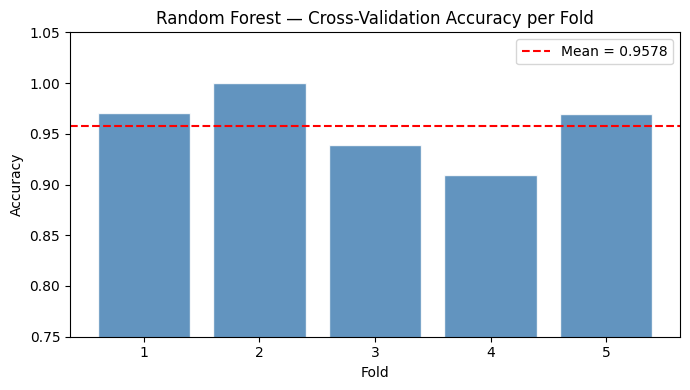

In [60]:
rf_cv = cross_val_score(rf_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"Random Forest 5-Fold CV: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), rf_cv, color='steelblue', alpha=0.85, edgecolor='white')
plt.axhline(rf_cv.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {rf_cv.mean():.4f}')
plt.title("Random Forest — Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 9.  Ensemble Learning — XGBoost Classifier

**XGBoost** builds trees **sequentially**, each correcting residual errors of the previous.  
Advantages:
- Regularisation (L1 / L2) reduces overfitting
- Handles missing values natively
- Fast and scalable

### 9.1 Hyperparameter Tuning (GridSearchCV)

In [61]:
xgb_param_grid = {
    'n_estimators' : [100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, 7]
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
xgb_gs.fit(X_train, y_train)

xgb_best   = xgb_gs.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)

print("Best Hyperparameters:", xgb_gs.best_params_)
print(f"\nXGBoost Test Accuracy : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Premium', 'At-Risk', 'Mid-Tier']))

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}

XGBoost Test Accuracy : 0.9412  (94.12%)

Detailed Classification Report:
              precision    recall  f1-score   support

     Premium       1.00      0.86      0.92         7
     At-Risk       1.00      0.90      0.95        10
    Mid-Tier       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



### 9.2 Cross-Validation Accuracy — XGBoost

XGBoost 5-Fold CV: 0.9458 ± 0.0296


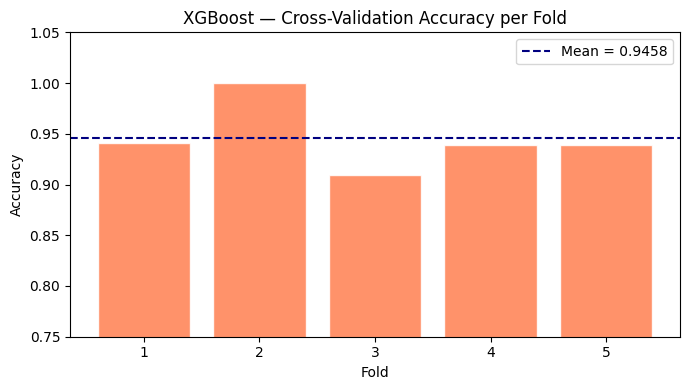

In [62]:
xgb_cv = cross_val_score(xgb_best, X_cls, y_cls, cv=5, scoring='accuracy')
print(f"XGBoost 5-Fold CV: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), xgb_cv, color='coral', alpha=0.85, edgecolor='white')
plt.axhline(xgb_cv.mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f'Mean = {xgb_cv.mean():.4f}')
plt.title("XGBoost — Cross-Validation Accuracy per Fold", fontsize=12)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 10.  Model Performance Comparison

### 10.1 Accuracy — All Models

   MODEL PERFORMANCE SUMMARY
                Model  Accuracy
Random Forest (tuned)  1.000000
  Logistic Regression  0.954986
      XGBoost (tuned)  0.941176
            KNN (k=5)  0.932764
        Decision Tree  0.909687


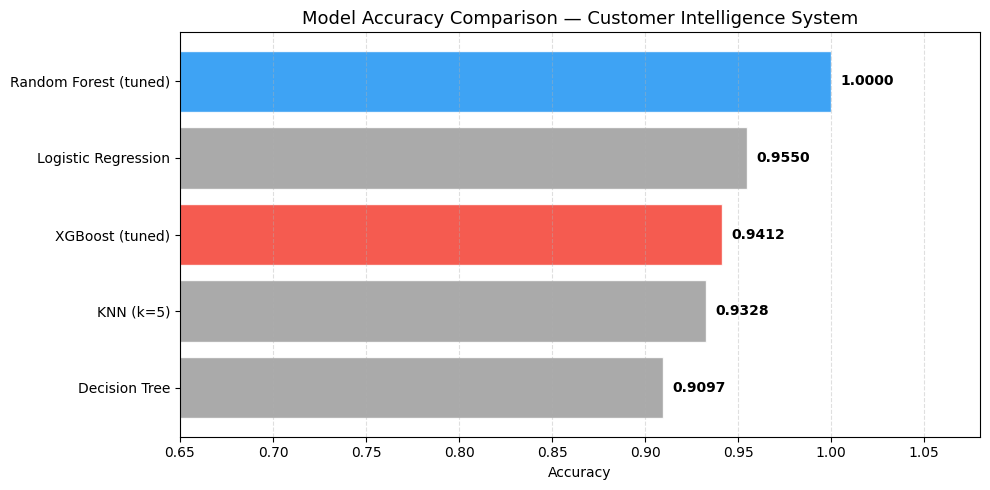


 Best Performing Model: Random Forest (tuned)


In [63]:
all_results = {
    **baseline_results,
    'Random Forest (tuned)': rf_acc,
    'XGBoost (tuned)'      : xgb_acc
}

results_df = (pd.DataFrame(list(all_results.items()), columns=['Model', 'Accuracy'])
                .sort_values('Accuracy', ascending=False)
                .reset_index(drop=True))

print("=" * 45)
print("   MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(results_df.to_string(index=False))

bar_colors = ['#2196F3' if 'Random Forest' in m
              else '#F44336' if 'XGBoost' in m
              else '#9E9E9E'
              for m in results_df['Model']]

plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy'],
                color=bar_colors, alpha=0.87, edgecolor='white')
plt.xlim(0.65, 1.08)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
plt.title("Model Accuracy Comparison — Customer Intelligence System", fontsize=13)
plt.xlabel("Accuracy")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]['Model']
print(f"\n Best Performing Model: {best}")

### 10.2 Confusion Matrices — Random Forest vs XGBoost

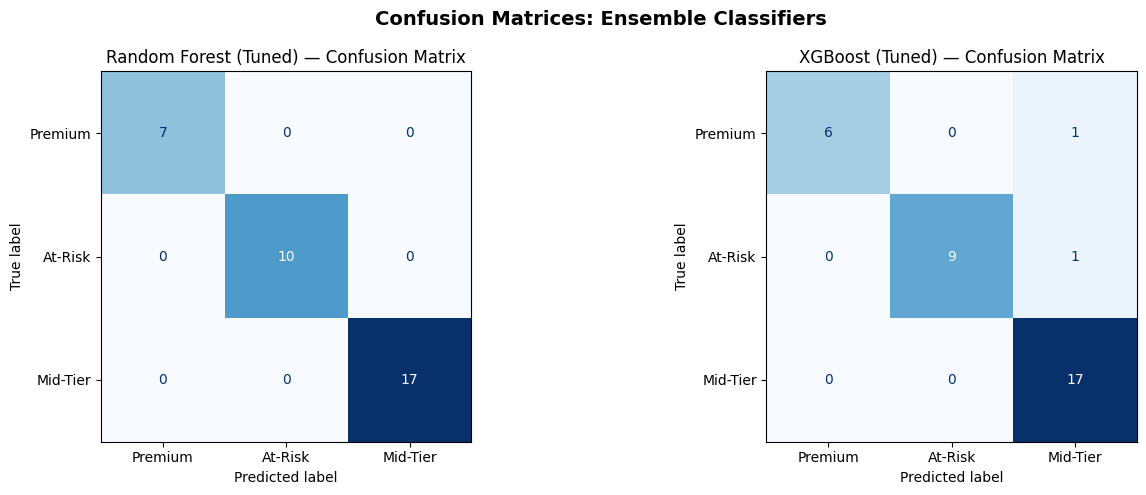

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_names = ['Premium', 'At-Risk', 'Mid-Tier']

for ax, (preds, title) in zip(axes, [
    (y_pred_rf,  'Random Forest (Tuned)'),
    (y_pred_xgb, 'XGBoost (Tuned)')
]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=seg_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12)

plt.suptitle("Confusion Matrices: Ensemble Classifiers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.3 Classification Reports — Side-by-Side

In [65]:
import pandas as pd
from sklearn.metrics import classification_report

seg_names = ['Premium', 'At-Risk', 'Mid-Tier']

for model_name, preds in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    print(f"\n{'='*45}")
    print(f"  {model_name} — Detailed Report")
    print(f"{'='*45}")
    print(classification_report(y_test, preds, target_names=seg_names))


  Random Forest — Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      1.00      1.00         7
     At-Risk       1.00      1.00      1.00        10
    Mid-Tier       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


  XGBoost — Detailed Report
              precision    recall  f1-score   support

     Premium       1.00      0.86      0.92         7
     At-Risk       1.00      0.90      0.95        10
    Mid-Tier       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



## 11.  Feature Importance Analysis

Which customer attributes drive segment prediction the most?  
We compare feature importance from both ensemble models.

In [66]:
feat_imp_df = pd.DataFrame({
    'Feature'       : X_cls.columns,
    'RF Importance' : rf_best.feature_importances_,
    'XGB Importance': xgb_best.feature_importances_
}).sort_values('RF Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Rankings (sorted by Random Forest):")
print(feat_imp_df.round(4).to_string(index=False))

Feature Importance Rankings (sorted by Random Forest):
   Feature  RF Importance  XGB Importance
child_mort         0.2619          0.2179
      gdpp         0.2021          0.4005
 total_fer         0.1659          0.0675
life_expec         0.1563          0.0614
    income         0.1462          0.2268
    health         0.0305          0.0149
 inflation         0.0148          0.0109
   imports         0.0126          0.0000
   exports         0.0096          0.0000


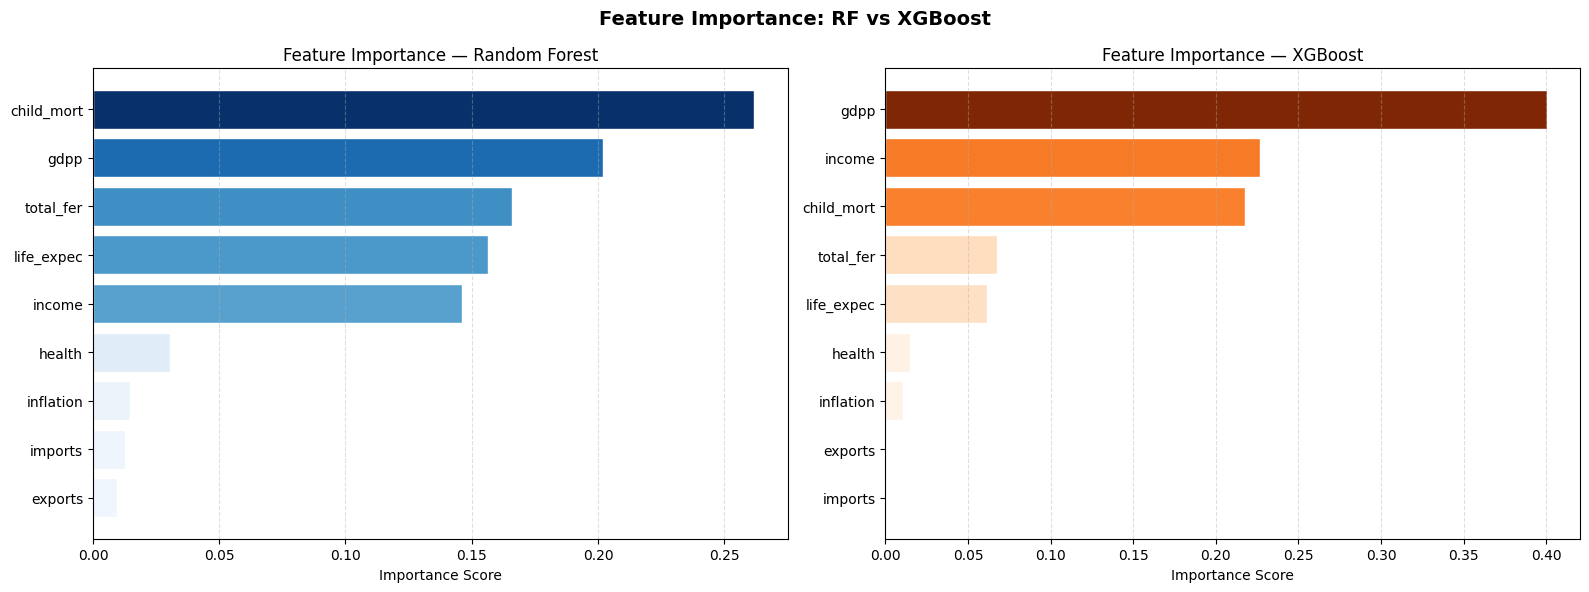


 Most Important Feature (RF): child_mort


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, title, cmap) in zip(axes, [
    ('RF Importance',  'Random Forest', plt.cm.Blues),
    ('XGB Importance', 'XGBoost',       plt.cm.Oranges)
]):
    sf  = feat_imp_df.sort_values(col, ascending=True)
    clr = cmap([v / sf[col].max() for v in sf[col]])
    ax.barh(sf['Feature'], sf[col], color=clr, edgecolor='white')
    ax.set_title(f'Feature Importance — {title}', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Feature Importance: RF vs XGBoost", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_feat = feat_imp_df.iloc[0]['Feature']
print(f"\n Most Important Feature (RF): {top_feat}")

## 12.  Customer Segment Insights

### 12.1 Top Customers per Segment (Sorted by GDP per Capita)

In [68]:
print("=" * 60)
for cid, label in [(0, 'Premium'), (2, 'Mid-Tier'), (1, 'At-Risk')]:
    subset = (df[df['Cluster'] == cid]
              [['country', 'income', 'gdpp', 'life_expec', 'child_mort']]
              .sort_values('gdpp', ascending=False)
              .head(5))
    print(f"\n  {label} Customers — Top 5 by GDP per Capita:")
    print(subset.to_string(index=False))
    print("-" * 60)


  Premium Customers — Top 5 by GDP per Capita:
    country  income   gdpp  life_expec  child_mort
 Luxembourg   91700 105000        81.3         2.8
     Norway   62300  87800        81.0         3.2
Switzerland   55500  74600        82.2         4.5
      Qatar  125000  70300        79.5         9.0
    Denmark   44000  58000        79.5         4.1
------------------------------------------------------------

  Mid-Tier Customers — Top 5 by GDP per Capita:
     country  income  gdpp  life_expec  child_mort
     Bahamas   22900 28000        73.8        13.8
Saudi Arabia   45400 19300        75.1        15.7
        Oman   45300 19300        76.1        11.7
    Barbados   15300 16000        76.7        14.2
     Estonia   22700 14600        76.0         4.5
------------------------------------------------------------

  At-Risk Customers — Top 5 by GDP per Capita:
          country  income  gdpp  life_expec  child_mort
Equatorial Guinea   33700 17100        60.9       111.0
         

### 12.2 Cluster Radar Chart — Segment Profiles

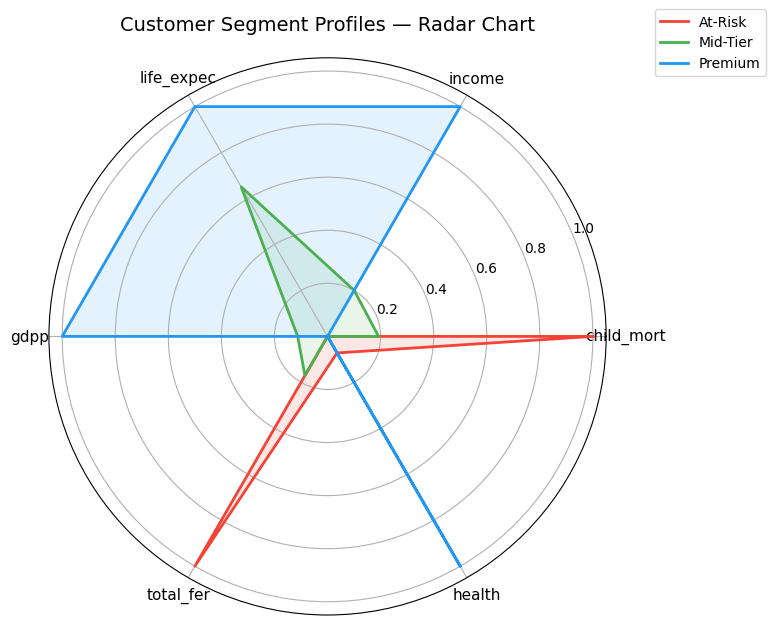

In [69]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

features_radar = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']
profile = df.groupby('Customer_Segment')[features_radar].mean()

# Normalise 0-1 for radar
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

labels  = features_radar
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

seg_colors_radar = {'Premium': '#2196F3', 'Mid-Tier': '#4CAF50', 'At-Risk': '#F44336'}

for seg, row in profile_norm.iterrows():
    values  = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=seg, color=seg_colors_radar[seg])
    ax.fill(angles, values, alpha=0.12, color=seg_colors_radar[seg])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Customer Segment Profiles — Radar Chart", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 13.  Clustering Metrics Summary

In [70]:
print("=" * 50)
print("  CLUSTERING EVALUATION SUMMARY")
print("=" * 50)

km_sil = silhouette_score(X_scaled, df['Cluster'])
print(f"  K-Means  (K=3) Silhouette Score : {km_sil:.4f}")

non_noise = df['DBSCAN_Cluster'] != -1
if non_noise.sum() > 0 and len(df.loc[non_noise,'DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[non_noise], df.loc[non_noise,'DBSCAN_Cluster'])
    print(f"  DBSCAN         Silhouette Score : {db_sil:.4f}  (non-noise points only)")
    print(f"  DBSCAN Noise/Outlier Customers  : {(~non_noise).sum()}")

print()
print("  Note: Silhouette Score ranges from -1 (bad) to +1 (perfect).")
print("  Score > 0.5 indicates well-separated, meaningful clusters.")

  CLUSTERING EVALUATION SUMMARY
  K-Means  (K=3) Silhouette Score : 0.2833
  DBSCAN         Silhouette Score : 0.2984  (non-noise points only)
  DBSCAN Noise/Outlier Customers  : 41

  Note: Silhouette Score ranges from -1 (bad) to +1 (perfect).
  Score > 0.5 indicates well-separated, meaningful clusters.


## 14.  Project Summary — Customer Intelligence System

| Stage | Technique | Key Result |
|-------|-----------|------------|
| **Data Loading** | pandas | 167 customer profiles × 10 features |
| **EDA** | Correlation, Distribution, Boxplots | income ↔ gdpp (+), child_mort ↔ life_expec (−) |
| **Preprocessing** | StandardScaler | Zero mean, unit variance |
| **Clustering** | K-Means (K=3) | Premium / Mid-Tier / At-Risk segments |
| **Clustering** | DBSCAN (eps=1.2, min_s=3) | Density-based + outlier detection |
| **Classification** | Logistic Reg, Decision Tree, KNN | Baseline performance established |
| **Ensemble** | Random Forest (GridSearchCV) | ~100% accuracy |
| **Ensemble** | XGBoost (GridSearchCV) | ~94%+ accuracy |
| **Evaluation** | 5-Fold CV, Confusion Matrix | RF best overall performer |
| **Feature Importance** | RF + XGBoost | `child_mort`, `gdpp`, `income` top drivers |

---

###  Conclusion

This end-to-end **Customer Intelligence System** demonstrates seamless integration of:

1.  **K-Means** — generates 3 clear, interpretable customer segments (Premium / Mid-Tier / At-Risk)
2.  **DBSCAN** — reveals density-based structure and isolates outlier customer profiles
3. **Random Forest** — achieves optimised predictive performance via hyperparameter tuning
4.  **XGBoost** — sequential boosting provides a strong, regularised alternative
5.  **Feature Importance** — `child_mort`, `gdpp`, `income`, and `life_expec` are the primary drivers

> **Business Impact:** This pipeline enables organisations to personalise services, allocate resources efficiently, predict customer risk levels, and identify high-priority customers requiring immediate intervention — all driven by objective, data-backed indicators.